In [2]:
import re
from math import comb
import matplotlib.pyplot as plt

In [3]:
def parse_d_string(d_string:str) -> tuple[int, int, int] :
    D_STRING_REG = r"(\d*)[Dd](\d+)([\+|\-]\d+)?"
    match = re.match(D_STRING_REG, d_string)
    if match is None :
        raise ValueError("d_string must conform to a [x]<Dy>[+z|-z] format (xyz being single or multy digit numbers).")
    k = match.groups()[0]
    k = int(k) if k is not None else 1
    n = int(match.groups()[1])
    b = match.groups()[2]
    b = int(b) if b is not None else 0
    return (k, n, b)

In [4]:
def get_outcomes_distrib(d_string:str) -> list[float] :
    k, n, b = parse_d_string(d_string)
    output = []
    for x in range(k+1) :
        output.append(comb(k, x) * pow(1/n, x) * pow(1-(1/n), k-x))
    return output

P(X=0)=0.161506
P(X=1)=0.323011
P(X=2)=0.29071
P(X=3)=0.155045
P(X=4)=0.054266
P(X=5)=0.013024
P(X=6)=0.002171
P(X=7)=0.000248
P(X=8)=1.9e-05
P(X=9)=1e-06
P(X=10)=0.0


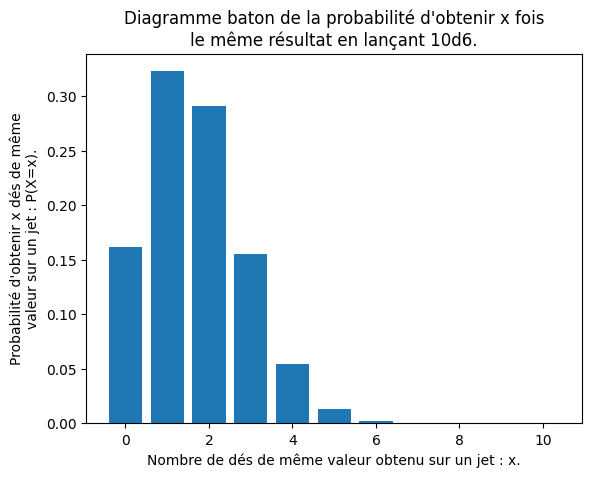

In [5]:
dice_throw = "10d6"

outcomes = get_outcomes_distrib(dice_throw)

fig, ax = plt.subplots()
ax.bar(range(len(outcomes)), outcomes)
ax.set_title(f"Diagramme baton de la probabilité d'obtenir x fois\nle même résultat en lançant {dice_throw}.")
ax.set_xlabel("Nombre de dés de même valeur obtenu sur un jet : x.")
ax.set_ylabel("Probabilité d'obtenir x dés de même\nvaleur sur un jet : P(X=x).")

for x, y in enumerate(outcomes) :
    print(f"P(X={x})={round(y, 6)}")